In [ ]:
import pandas as pd


df = pd.read_csv('/content/drive/MyDrive/DX PROJ./층간소음데이터통합_영어제거완료.csv')

In [ ]:
df

,제목,본문,token
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']"
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']"
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']"
...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다..."
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '..."
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '..."
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자..."


In [ ]:
# '본문' 컬럼에 NaN이 있는 행만 삭제
df.dropna(subset=['본문'], inplace=True)

In [ ]:
df

,제목,본문,token
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']"
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']"
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']"
...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다..."
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '..."
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '..."
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자..."


In [ ]:
!pip install sentence-transformers torch transformers

In [ ]:
import torch

# GPU가 연결되었는지 확인하는 코드
if torch.cuda.is_available():
    print(f"성공! 현재 사용 가능한 GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU 연결 실패... CPU 모드입니다.")

성공! 현재 사용 가능한 GPU: Tesla T4


In [ ]:
!pip install -U sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

# 모델 불러오기
model = SentenceTransformer('jhgan/ko-sroberta-multitask')

print("모델 로드 완료!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

모델 로드 완료!


In [ ]:
# 1. '통합본문' 컬럼에 결측치가 있는 행을 제거합니다.
df = df.dropna(subset=['본문'])

# 2. (혹시 모르니) 모든 데이터를 문자열 타입으로 확실히 변환합니다.
text_list = df['본문'].astype(str).tolist()

# 3. 다시 임베딩을 진행합니다.
print(f"총 {len(text_list)}개의 문장을 임베딩합니다...")
embeddings = model.encode(text_list, show_progress_bar=True)

# 4. 결과 확인
print("임베딩 완료! 형태:", embeddings.shape)

총 58566개의 문장을 임베딩합니다...


Batches:   0%|          | 0/1831 [00:00<?, ?it/s]

임베딩 완료! 형태: (58566, 768)


In [ ]:
df

,제목,본문,token
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']"
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']"
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']"
...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다..."
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '..."
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '..."
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자..."


In [ ]:
# 1. 생성된 임베딩 벡터를 리스트 형태로 변환하여 새로운 'embedding' 컬럼에 할당
df['embedding'] = embeddings.tolist()

# 2. 결과 확인 (embedding 컬럼이 잘 들어갔는지 확인)
display(df.head())

,제목,본문,token,embedding
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']","[-0.5792470574378967, -0.3509799838066101, -0...."
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']","[-0.6158533692359924, -0.061289992183446884, 0..."
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...","[-0.14360012114048004, -0.005446251481771469, ..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...","[-0.5051539540290833, -0.6635602712631226, 0.2..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']","[-0.8485231399536133, -0.4335775673389435, 0.0..."


In [ ]:
# (선택) 데이터프레임 저장 예시
df.to_pickle("embedded_data bert.pkl")

-----------------------------
여기부터 수정

In [4]:
import pandas as pd
import pickle

# 판다스로 피클 파일 바로 읽기
df = pd.read_pickle("embedded_data bert.pkl")

print("✅ 데이터프레임 로드 완료!")
display(df.head())

✅ 데이터프레임 로드 완료!


,제목,본문,token,embedding
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']","[-0.5792470574378967, -0.3509799838066101, -0...."
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']","[-0.6158533692359924, -0.061289992183446884, 0..."
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...","[-0.14360012114048004, -0.005446251481771469, ..."
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...","[-0.5051539540290833, -0.6635602712631226, 0.2..."
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']","[-0.8485231399536133, -0.4335775673389435, 0.0..."


In [5]:
import ast
import numpy as np

# 1. 만약 컬럼명이 지정되어 있지 않다면, 4번째 컬럼(인덱스 3)의 이름을 'embedding'으로 지정해줍니다.
# (출력해주신 데이터 구조상 4번째 열에 벡터가 들어있기 때문입니다)
df.columns = ['제목', '본문', 'token', 'embedding']  # 필요에 따라 컬럼명을 맞춰주세요

# 2. [치트키] 문자열(str)로 인식된 벡터를 실제 파이썬 리스트(숫자) 형태로 변환합니다.
# 데이터가 6만 건이기 때문에, 타입이 문자열(str)인 경우에만 안전하게 숫자로 파싱해줍니다.
if isinstance(df['embedding'].iloc[0], str):
    print("🔄 문자열로 된 벡터를 숫자 배열로 변환 중입니다... (6만 건 기준 약 10~20초 소요)")
    df['embedding'] = df['embedding'].apply(ast.literal_eval)

# 3. [최종 단계] 리스트들의 시리즈를 UMAP/PCA가 좋아하는 거대한 하나의 넘파이 행렬로 결합합니다.
bert_embeddings = np.array(df['embedding'].tolist())

# 4. 성공적으로 만들어졌는지 모양새(Shape) 확인하기
print("✅ bert_embeddings 준비 완료!")
print(f"📊 Matrix Shape: {bert_embeddings.shape}")
# 정상적이라면 (60000, 1536) 혹은 (60000, 768) 형태로 행렬 크기가 출력됩니다.

✅ bert_embeddings 준비 완료!
📊 Matrix Shape: (58566, 768)


### 150차원, 5차원

In [8]:

from sklearn.decomposition import PCA
from umap import UMAP

# bert_embeddings.shape가 (60000, 768)인 상황 가정

# -------------------------------------------------------------
# [1단계] PCA로 거대한 차원의 노이즈를 빠르게 거르고 경량화 (768D -> 100D)
# -------------------------------------------------------------
print("🚀 1단계: PCA 차원 축소 시작...")
pca = PCA(n_components=150, random_state=42) # 100차원~150차원 추천
embeddings_pca = pca.fit_transform(bert_embeddings)
print(f"✅ PCA 완료! 배열 모양: {embeddings_pca.shape}")
# 결과: (60000, 100) -> 이제 컴퓨터가 숨을 쉴 수 있는 크기가 되었습니다.


# -------------------------------------------------------------
# [2단계] 가벼워진 PCA 배열을 UMAP에 넣어 정밀한 공간 구축 (100D -> 5D 또는 10D)
# -------------------------------------------------------------
print("\n🚀 2단계: UMAP 정밀 차원 축소 시작 (이웃 관계 계산)...")
# 6만 건이므로 n_neighbors를 15~30 정도로 여유 있게 주어 거대한 흐름을 잡습니다.
umap_model = UMAP(n_components=5, n_neighbors=30, min_dist=0.1, random_state=42)
embeddings_umap = umap_model.fit_transform(embeddings_pca)
print(f"✅ UMAP 완료! 최종 배열 모양: {embeddings_umap.shape}")


# -------------------------------------------------------------
# [3단계] 이 최종 고도화 배열을 가지고 최적의 K 사냥하러 가기
# -------------------------------------------------------------
# 이 embeddings_umap 배열을 가지고 이전에 구상하셨던
# 엘보우 기법(Elbow)과 실루엣 지수(Silhouette) 코드를 돌리시면 됩니다!

🚀 1단계: PCA 차원 축소 시작...
✅ PCA 완료! 배열 모양: (58566, 150)

🚀 2단계: UMAP 정밀 차원 축소 시작 (이웃 관계 계산)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP 완료! 최종 배열 모양: (58566, 5)


🔄 [검증] 10차원 UMAP 공간 위에서 최적의 K 사냥 시작... (약 1~2분 소요)

📊 [K = 2] 연산 완료 | Inertia: 227622.11 | Silhouette Score: 0.8624
📊 [K = 3] 연산 완료 | Inertia: 180931.41 | Silhouette Score: 0.4532
📊 [K = 4] 연산 완료 | Inertia: 153539.58 | Silhouette Score: 0.4557
📊 [K = 5] 연산 완료 | Inertia: 134898.69 | Silhouette Score: 0.4693
📊 [K = 6] 연산 완료 | Inertia: 115965.35 | Silhouette Score: 0.4436
📊 [K = 7] 연산 완료 | Inertia: 107329.19 | Silhouette Score: 0.4424
📊 [K = 8] 연산 완료 | Inertia: 91647.64 | Silhouette Score: 0.4456

✅ 모든 연산이 완료되었습니다! 그래프를 그립니다.


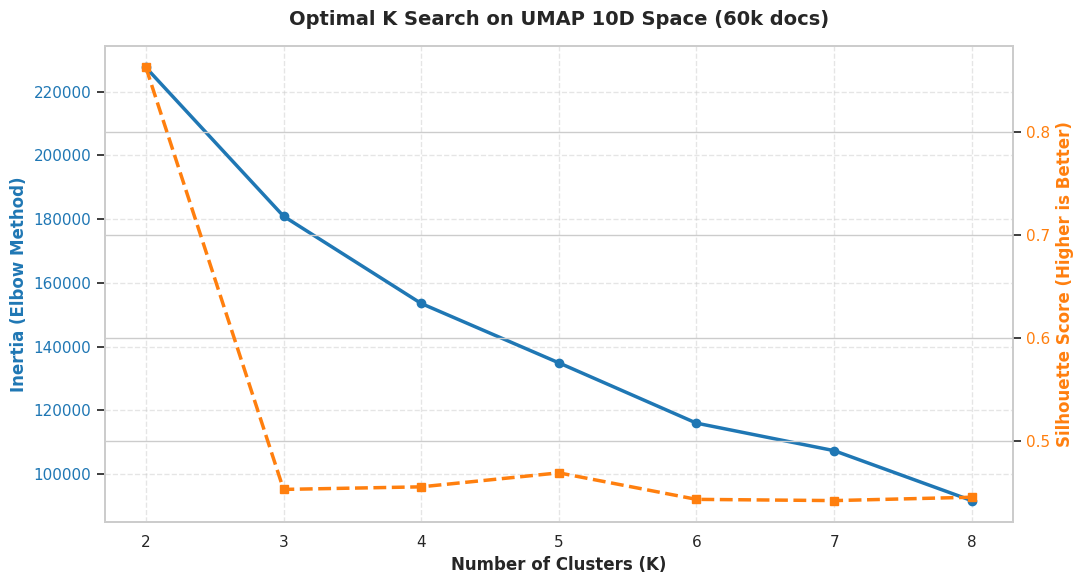

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. 6만 건 데이터 중 실루엣 계산용 5,000건 샘플링 (속도 및 메모리 보호)
np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(embeddings_umap), size=sample_size, replace=False)
umap_sample = embeddings_umap[sample_idx]

inertia_list = []
silhouette_list = []
k_range = range(2, 9)  # K = 2개부터 8개까지 방 개수 테스트

print("🔄 10차원 UMAP 공간 위에서 최적의 K 사냥 시작... (약 1분 소요)\n")

for k in k_range:
    # KMeans 모델 선언
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)

    # [엘보우] Inertia는 전체 데이터(6만 건)를 완벽히 반영하여 학습
    kmeans.fit(embeddings_umap)
    inertia_list.append(kmeans.inertia_)

    # [실루엣] 추출한 샘플 데이터(5,000건)로 예측 및 분리도 계산
    sample_labels = kmeans.predict(umap_sample)
    score = silhouette_score(umap_sample, sample_labels)
    silhouette_list.append(score)

    print(f"📊 [K = {k}] 연산 완료 | Inertia: {kmeans.inertia_:.2f} | Silhouette Score: {score:.4f}")

print("\n✅ 모든 연산이 완료되었습니다! 그래프를 그립니다.")

# 2. 이중 축(Dual-Axis) 시각화 그래프 그리기
fig, ax1 = plt.subplots(figsize=(11, 6))

# 엘보우 기법 (왼쪽 Y축 - 파란색 실선)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inertia (Elbow Method)', color=color, fontweight='bold', fontsize=12)
ax1.plot(k_range, inertia_list, marker='o', color=color, linewidth=2.5, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# 실루엣 지수 (오른쪽 Y축 - 주황색 점선)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score (Higher is Better)', color=color, fontweight='bold', fontsize=12)
ax2.plot(k_range, silhouette_list, marker='s', color=color, linewidth=2.5, linestyle='--', label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal K Search on UMAP 5D Space (60k docs)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. 마음의 결정을 내린 최종 K값 설정
final_k = 4

print(f"🚀 확정된 K={final_k}로 최종 K-Means 군집화 가동...")
final_kmeans = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)

# 5차원 UMAP 배열을 이용해 정밀 학습 및 예측
# (앞 셀에서 만든 embeddings_umap을 그대로 사용합니다)
df['cluster'] = final_kmeans.fit_predict(embeddings_umap)

print("📊 각 군집별 데이터 배정 개수 확인:")
print(df['cluster'].value_counts())

# 2. [치트키] 이제 다음 단계(LDA, TF-IDF)를 위해 데이터프레임을 피클로 안전하게 저장
df.to_pickle("층간소음_군집완료_4.pkl")


🚀 확정된 K=4로 최종 K-Means 군집화 가동...
📊 각 군집별 데이터 배정 개수 확인:
cluster
0    26670
2    16752
1    15002
3      142
Name: count, dtype: int64


🔄 현재 10차원 배열이므로, 시각화를 위해 2차원 UMAP 플롯을 추가 생성합니다...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


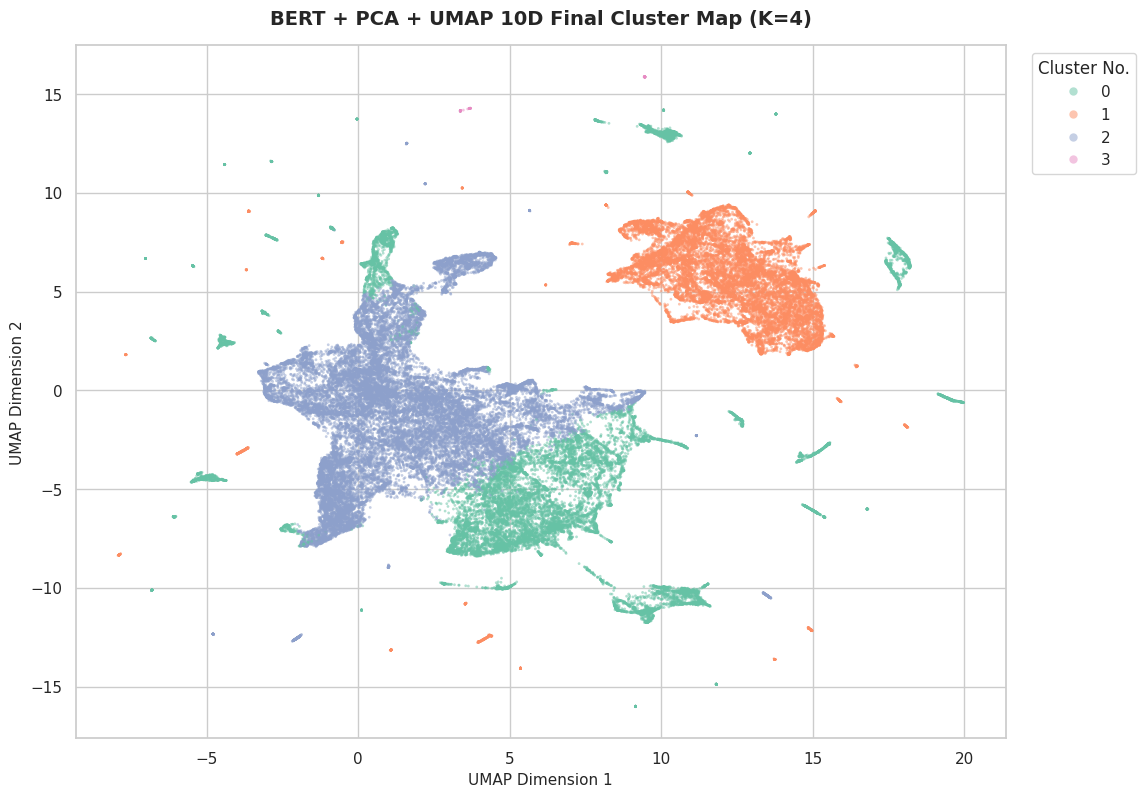

🎉 축하합니다! 4개 방으로 선명하게 분할된 10차원 최종 색상 지도가 'umap_10d_final_cluster_map.png'로 저장되었습니다!


In [20]:
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화용 2차원 투영 데이터 생성 (★10차원 전용 배열인 embeddings_umap_10d 로 변경 완료)
if embeddings_umap_10d.shape[1] > 2:
    print(f"🔄 현재 {embeddings_umap_10d.shape[1]}차원 배열이므로, 시각화를 위해 2차원 UMAP 플롯을 추가 생성합니다...")
    # 거대한 흐름을 안정적으로 유지하기 위해 n_neighbors=30 세팅 유지
    umap_2d = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42, n_jobs=-1)
    viz_data = umap_2d.fit_transform(embeddings_umap_10d)
else:
    viz_data = embeddings_umap_10d

# --- 시각화 그래프 그리기 ---
plt.figure(figsize=(12, 9))
sns.set_theme(style='whitegrid')

# ★ [수정 핵심 포인트] ★
# hue 대상을 10차원 전용 군집 레이블인 df['cluster_10d']로 완벽 매칭했습니다.
sns.scatterplot(
    x=viz_data[:, 0],
    y=viz_data[:, 1],
    hue=df['cluster_10d'],  # 10차원 K-Means 방 번호 컬럼 입력
    palette='Set2',         # 눈 피로도가 적고 이쁜 파스텔톤 컬러 테마
    alpha=0.5,              # 6만 건의 밀도를 정밀하게 보기 위한 투명도
    s=4,                    # 대용량 점들의 뭉침을 예쁘게 표현하는 최적 크기
    linewidth=0             # 점들의 검은 테두리를 제거하여 대륙 색상을 선명하게 보존
)

# 그래프 제목 및 축 이름 레이블링 (★10D 정보를 명시하여 혼선 방지)
plt.title(f"BERT + PCA + UMAP 10D Final Cluster Map (K={df['cluster_10d'].nunique()})", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=11)
plt.ylabel("UMAP Dimension 2", fontsize=11)

# 범례(Legend) 상자를 그래프 우측 바깥 영역으로 깔끔하게 격리
plt.legend(title="Cluster No.", bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=3)

# ★ 파일명도 5차원 결과와 덮어써지지 않게 'umap_10d_final_cluster_map.png'로 분리 저장
plt.savefig("umap_10d_final_cluster_map.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"🎉 축하합니다! {df['cluster_10d'].nunique()}개 방으로 선명하게 분할된 10차원 최종 색상 지도가 'umap_10d_final_cluster_map.png'로 저장되었습니다!")

In [16]:
# 현재 메모리에 올라온 UMAP 배열의 크기 확인
print("📊 현재 배열의 모양(Shape):", embeddings_umap.shape)

📊 현재 배열의 모양(Shape): (58566, 10)


### 150차원, 10차원

In [13]:

from sklearn.decomposition import PCA
from umap import UMAP

# bert_embeddings.shape가 (60000, 768)인 상황 가정

# -------------------------------------------------------------
# [1단계] PCA로 거대한 차원의 노이즈를 빠르게 거르고 경량화 (768D -> 100D)
# -------------------------------------------------------------
print("🚀 1단계: PCA 차원 축소 시작...")
pca = PCA(n_components=150, random_state=42) # 100차원~150차원 추천
embeddings_pca = pca.fit_transform(bert_embeddings)
print(f"✅ PCA 완료! 배열 모양: {embeddings_pca.shape}")
# 결과: (60000, 100) -> 이제 컴퓨터가 숨을 쉴 수 있는 크기가 되었습니다.


# -------------------------------------------------------------
# [2단계] 가벼워진 PCA 배열을 UMAP에 넣어 정밀한 공간 구축 (100D -> 5D 또는 10D)
# -------------------------------------------------------------
print("\n🚀 2단계: UMAP 정밀 차원 축소 시작 (이웃 관계 계산)...")
# 6만 건이므로 n_neighbors를 15~30 정도로 여유 있게 주어 거대한 흐름을 잡습니다.
umap_model = UMAP(n_components=10, n_neighbors=30, min_dist=0.1, random_state=42)
embeddings_umap = umap_model.fit_transform(embeddings_pca)
print(f"✅ UMAP 완료! 최종 배열 모양: {embeddings_umap.shape}")


# -------------------------------------------------------------
# [3단계] 이 최종 고도화 배열을 가지고 최적의 K 사냥하러 가기
# -------------------------------------------------------------
# 이 embeddings_umap 배열을 가지고 이전에 구상하셨던
# 엘보우 기법(Elbow)과 실루엣 지수(Silhouette) 코드를 돌리시면 됩니다!

🚀 1단계: PCA 차원 축소 시작...
✅ PCA 완료! 배열 모양: (58566, 150)

🚀 2단계: UMAP 정밀 차원 축소 시작 (이웃 관계 계산)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ UMAP 완료! 최종 배열 모양: (58566, 10)


🚀 [강제 갱신] 1단계: 10차원 UMAP 압축 연산 시작합니다...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


📊 [검증] 현재 메모리에 생성된 배열의 실제 모양(Shape):
(58566, 10)

🔄 2단계: 따끈따끈한 10차원 데이터로 엘보우/실루엣 재계산 중...
📊 [10D / K = 2] Inertia: 227622.11 | Silhouette: 0.8624
📊 [10D / K = 3] Inertia: 180931.41 | Silhouette: 0.4532
📊 [10D / K = 4] Inertia: 153539.58 | Silhouette: 0.4557
📊 [10D / K = 5] Inertia: 134898.69 | Silhouette: 0.4693
📊 [10D / K = 6] Inertia: 115965.35 | Silhouette: 0.4436
📊 [10D / K = 7] Inertia: 107329.19 | Silhouette: 0.4424
📊 [10D / K = 8] Inertia: 91647.64 | Silhouette: 0.4456

🎨 3단계: 10차원 전용 성적표 그래프를 그립니다.


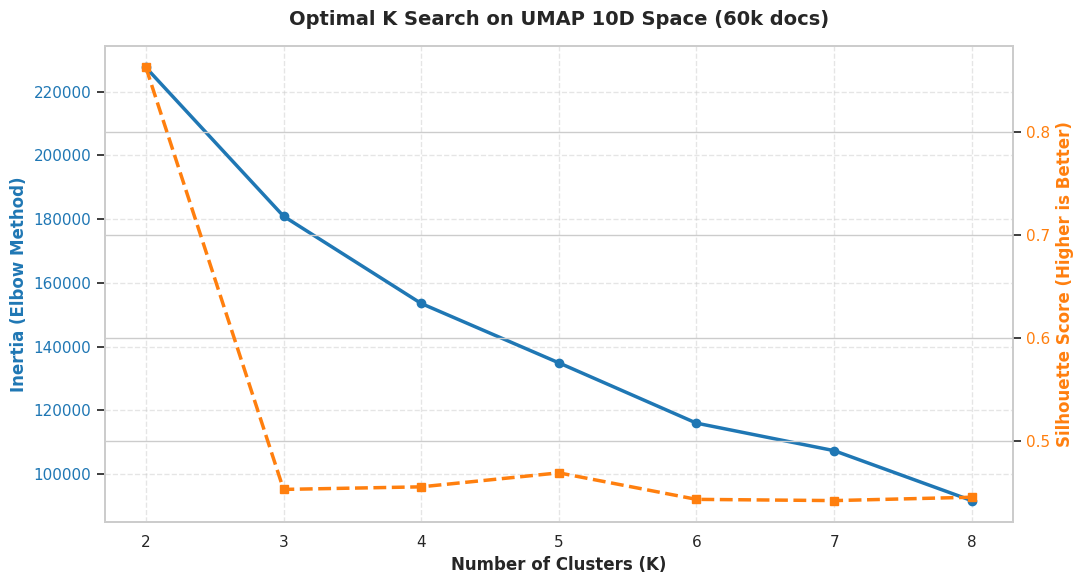

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# =============================================================
# [STEP 1] 이름을 완전히 다르게 해서 10차원 UMAP 강제 새출발
# =============================================================
print("🚀 [강제 갱신] 1단계: 10차원 UMAP 압축 연산 시작합니다...")

umap_10d_forced = UMAP(n_components=10, n_neighbors=30, min_dist=0.1, random_state=42, n_jobs=-1)
# 꼬임 방지를 위해 변수명을 완전히 'embeddings_umap_10d'로 차별화합니다.
embeddings_umap_10d = umap_10d_forced.fit_transform(embeddings_pca)

print("📊 [검증] 현재 메모리에 생성된 배열의 실제 모양(Shape):")
print(embeddings_umap_10d.shape)
# -> 반드시 (60000, 10)이 찍혀야 정상입니다! 확인해보세요.


# =============================================================
# [STEP 2] 새로 태어난 10차원 배열(embeddings_umap_10d)로 곧바로 K 사냥
# =============================================================
print("\n🔄 2단계: 따끈따끈한 10차원 데이터로 엘보우/실루엣 재계산 중...")

np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(embeddings_umap_10d), size=sample_size, replace=False)
umap_sample = embeddings_umap_10d[sample_idx]

inertia_list = []
silhouette_list = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)

    # 10차원 배열 적용
    kmeans.fit(embeddings_umap_10d)
    inertia_list.append(kmeans.inertia_)

    sample_labels = kmeans.predict(umap_sample)
    score = silhouette_score(umap_sample, sample_labels)
    silhouette_list.append(score)

    print(f"📊 [10D / K = {k}] Inertia: {kmeans.inertia_:.2f} | Silhouette: {score:.4f}")


# =============================================================
# [STEP 3] 10차원 전용 이중 축 그래프 시각화
# =============================================================
print("\n🎨 3단계: 10차원 전용 성적표 그래프를 그립니다.")
fig, ax1 = plt.subplots(figsize=(11, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (K)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Inertia (Elbow Method)', color=color, fontweight='bold', fontsize=12)
ax1.plot(k_range, inertia_list, marker='o', color=color, linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score (Higher is Better)', color=color, fontweight='bold', fontsize=12)
ax2.plot(k_range, silhouette_list, marker='s', color=color, linewidth=2.5, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal K Search on UMAP 10D Space (60k docs)', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

In [19]:
from sklearn.cluster import KMeans
import pandas as pd

# 1. 10차원 성적표를 보고 마음의 결정을 내린 최종 K값 설정
final_k = 4  # 만약 10차원 지표를 보고 방을 5개로 늘리고 싶다면 이 숫자만 5로 바꾸세요!

print(f"🚀 [10차원 공간 기반] 확정된 K={final_k}로 최종 K-Means 군집화 가동...")
final_kmeans = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)

# ★ [수정 핵심 1] 꼬임 방지 통합 셀에서 만든 10차원 넘파이 배열(embeddings_umap_10d)을 지정합니다.
# ★ [수정 핵심 2] 컬럼명도 5차원과 헷갈리지 않게 'cluster_10d'로 깔끔하게 분리합니다.
df['cluster_10d'] = final_kmeans.fit_predict(embeddings_umap_10d)

print("\n📊 10차원 군집별 데이터 배정 개수 확인:")
print(df['cluster_10d'].value_counts())

# ★ [수정 핵심 3] 파일명에 10d를 명시하여 최종 결과물을 안전하게 분리 저장합니다.
output_filename = f"층간소음_군집완료_10d_{final_k}.pkl"
df.to_pickle(output_filename)

print(f"\n🎉 대장정 완료! 10차원 군집 결과가 반영된 데이터프레임이 '{output_filename}'로 안전하게 박제되었습니다.")

🚀 [10차원 공간 기반] 확정된 K=4로 최종 K-Means 군집화 가동...

📊 10차원 군집별 데이터 배정 개수 확인:
cluster_10d
2    26379
0    17098
1    15002
3       87
Name: count, dtype: int64

🎉 대장정 완료! 10차원 군집 결과가 반영된 데이터프레임이 '층간소음_군집완료_10d_4.pkl'로 안전하게 박제되었습니다.


In [ ]:
#150차원, 5차원


import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화용 2차원 투영 데이터 생성 (기존 조건 유지)
if embeddings_umap.shape[1] > 2:
    print(f"🔄 현재 {embeddings_umap.shape[1]}차원 배열이므로, 시각화를 위해 2차원 UMAP 플롯을 추가 생성합니다...")
    umap_2d = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42, n_jobs=-1)
    viz_data = umap_2d.fit_transform(embeddings_umap)
else:
    viz_data = embeddings_umap

# --- 시각화 그래프 그리기 ---
# 범례(Legend)가 우측에 붙으므로 가로 너비를 12로 살짝 넓혀주는 것이 정석입니다.
plt.figure(figsize=(12, 9))
sns.set_theme(style='whitegrid')

# ★ [수정 핵심 포인트] ★
# color 지정을 빼고, hue에 방 번호 컬럼을 지정한 뒤 아름다운 팔레트를 입힙니다.
sns.scatterplot(
    x=viz_data[:, 0],
    y=viz_data[:, 1],
    hue=df['cluster'],  # 데이터프레임의 진짜 K-Means 방 번호 컬럼 입력
    palette='Set2',      # 아까 마음에 들어 하셨던 깔끔하고 예쁜 파스텔톤 색상 조합 (또는 'tab10')
    alpha=0.5,           # 6만 건의 겹침 밀도를 보기 위한 투명도 조절
    s=4,                 # 점의 크기 (대규모 데이터이므로 3~4가 가장 이쁩니다)
    linewidth=0          # ★중요: 점 테두리를 0으로 없애야 점들이 뭉쳤을 때 검은 테두리 때문에 색상이 칙칙해지지 않습니다.
)

# 그래프 제목 및 축 이름 레이블링
plt.title(f"BERT + PCA + UMAP 2D Final Cluster Map (K={df['cluster'].nunique()})", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("UMAP Dimension 1", fontsize=11)
plt.ylabel("UMAP Dimension 2", fontsize=11)

# 범례(어떤 색이 몇 번 방인지 설명하는 상자)를 그래프 우측 바깥으로 깔끔하게 빼줍니다.
plt.legend(title="Cluster No.", bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=3)

# 코랩에서 그래프를 이미지 파일로 고화질 저장 (발표 장표 백업용)
plt.savefig("umap_final_cluster_map.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"🎉 축하합니다! {df['cluster'].nunique()}개 방으로 선명하게 분할된 최종 색상 지도가 'umap_final_cluster_map.png'로 저장되었습니다!")

🔄 현재 5차원 배열이므로, 시각화를 위해 2차원 UMAP 플롯을 추가 생성합니다...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [6]:
!install pickle

install: missing destination file operand after 'pickle'
Try 'install --help' for more information.


In [8]:
import pickle
# 1. UMAP으로 축소 완료한 넘파이 배열 저장 (pickle.dump 사용)
with open("embeddings_umap_5d.pkl", "wb") as f:
    pickle.dump(embeddings_umap, f)


print("✅ UMAP 배열 및 KMeans 모델 객체 피클 저장 완료!")

✅ UMAP 배열 및 KMeans 모델 객체 피클 저장 완료!


--------------------------
위에 이제 버려도 됨 여기부터 다시 시작


In [22]:
import pandas as pd

# 1. 업로드한 5차원 피클 파일명을 적어줍니다 (파일명이 다르면 수정해 주세요!)
file_path = "층간소음_군집완료_4.pkl"

# 2. 판다스 내장 함수로 피클 안전하게 불러오기
df = pd.read_pickle(file_path)

print("🎉 5차원 군집 마스터 데이터프레임 로드 완료!")
print(f"📊 전체 데이터 개수: {len(df)}건\n")

# 3. 데이터가 원형 그대로 잘 들어왔는지 눈으로 확인
print("🔹 [확인 1] 데이터 상위 3개 행 확인:")
display(df.head(3))

print("\n🔹 [확인 2] 5차원 기반 군집별 배정 개수 다시 확인:")
if 'cluster' in df.columns:
    print(df['cluster'].value_counts())
else:
    # 혹시 컬럼명을 다른 이름으로 저장하셨다면 해당 컬럼명을 출력합니다.
    print("⚠️ 'cluster' 컬럼명을 찾을 수 없습니다. 현재 컬럼 목록을 확인하세요:")
    print(df.columns)

🎉 5차원 군집 마스터 데이터프레임 로드 완료!
📊 전체 데이터 개수: 58566건

🔹 [확인 1] 데이터 상위 3개 행 확인:


,제목,본문,token,embedding,cluster
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']","[-0.5792470574378967, -0.3509799838066101, -0....",0
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']","[-0.6158533692359924, -0.061289992183446884, 0...",0
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...","[-0.14360012114048004, -0.005446251481771469, ...",0



🔹 [확인 2] 5차원 기반 군집별 배정 개수 다시 확인:
cluster
0    26670
2    16752
1    15002
3      142
Name: count, dtype: int64


In [23]:
import pickle

# UMAP 5차원 좌표 배열 피클 파일 불러오기
with open("embeddings_umap_5d.pkl", "rb") as f:
    embeddings_umap = pickle.load(f)

print("✅ 5차원 UMAP 좌표 배열 로드 완료! 모양(Shape):", embeddings_umap.shape)

✅ 5차원 UMAP 좌표 배열 로드 완료! 모양(Shape): (58566, 5)


In [26]:
# 클러스터 3: 142개, 노이즈로 판단하고 제외하기 전 마지막 확인하기

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# -------------------------------------------------------------
# [준비 단계] token 컬럼이 리스트 형태라면 문자열로 합쳐줍니다.
# -------------------------------------------------------------
# 데이터프레임 이름은 df, 토큰 컬럼은 'token', 본문 컬럼은 '본문' 기준
if isinstance(df['token'].iloc[0], list):
    df['token_str'] = df['token'].apply(lambda x: ' '.join(x) if isinstance(x, list) else '')
else:
    df['token_str'] = df['token'].fillna('')

# -------------------------------------------------------------
# [1단계] 군집별 고유 단어를 찾기 위한 대조군 TF-IDF 연산
# (4개 방의 텍스트를 각각 통째로 합쳐서 서로 비교 분석합니다)
# -------------------------------------------------------------
cluster_docs = df.groupby('cluster')['token_str'].apply(lambda x: ' '.join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(cluster_docs['token_str'])
feature_names = np.array(vectorizer.get_feature_names_out())

# 3번 군집의 행 인덱스 찾기
target_cluster = 3
target_row_idx = cluster_docs[cluster_docs['cluster'] == target_cluster].index[0]

# 3번 군집에서 TF-IDF 점수가 가장 높은 상위 20개 단어 추출
row_scores = tfidf_matrix.getrow(target_row_idx).toarray()[0]
top_word_indices = row_scores.argsort()[-20:][::-1]

print("=" * 60)
print(f"🚨 [검증 1] {target_cluster}번 군집을 대표하는 고유 TF-IDF 키워드 Top 20")
print("=" * 60)
for rank, idx in enumerate(top_word_indices, 1):
    if row_scores[idx] > 0:
        print(f"{rank:2d}등 | 단어: {feature_names[idx]:<10} | 점수: {row_scores[idx]:.4f}")

print("\n" + "=" * 60)
print(f"📄 [검증 2] {target_cluster}번 군집의 실제 본문 데이터 무작위 샘플 (15개)")
print("=" * 60)

# 3번 군집 글 중에서 15개를 뽑아 본문 내용을 확인합니다.
sample_texts = df[df['cluster'] == target_cluster]['본문'].dropna().sample(n=min(15, df[df['cluster'] == target_cluster].shape[0]), random_state=42)

for i, text in enumerate(sample_texts, 1):
    # 가독성을 위해 150자까지만 자르고, 줄바꿈은 공백으로 처리해서 출력
    clean_text = str(text).replace('\n', ' ').strip()
    print(f"[{i:2d}] {clean_text[:150]}...")
print("=" * 60)

🚨 [검증 1] 3번 군집을 대표하는 고유 TF-IDF 키워드 Top 20
 1등 | 단어: 수집         | 점수: 0.5774
 2등 | 단어: 실패         | 점수: 0.5774
 3등 | 단어: 본문         | 점수: 0.5774

📄 [검증 2] 3번 군집의 실제 본문 데이터 무작위 샘플 (15개)
[ 1] 본문 수집 실패...
[ 2] 본문 수집 실패...
[ 3] 본문 수집 실패...
[ 4] 본문 수집 실패...
[ 5] 본문 수집 실패...
[ 6] 본문 수집 실패...
[ 7] 본문 수집 실패...
[ 8] 본문 수집 실패...
[ 9] 본문 수집 실패...
[10] 본문 수집 실패...
[11] 본문 수집 실패...
[12] 본문 수집 실패...
[13] 본문 수집 실패...
[14] 본문 수집 실패...
[15] 본문 수집 실패...


# kmeans

PCA 차원 축소 진행 중...
차원 축소 완료! 데이터 형태: (58566, 50)
엘보우 그래프 생성 중...


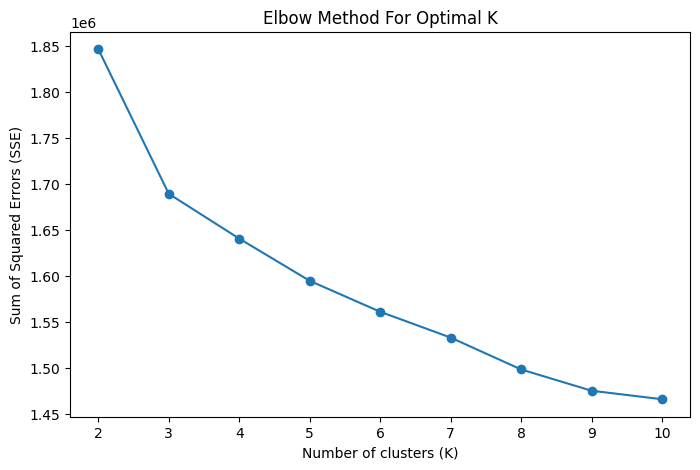


K=3로 K-Means 최종 군집화 진행 중...
군집화 완료!


,본문,token,cluster
0,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']",2
1,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']",2
2,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...",0
3,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...",2
4,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']",0
5,윗집 남자 피해자 죽임당하셔구냐 불쌍해요 층간소음 윗층 할머니 새벽 시에 믹서기 돌...,"['집', '남자', '피해자', '죽이다', '당하다', '구', '불쌍하다', ...",2
6,인간이길 포기한 숨쉬며 꿈틀꿈틀 움직이는 물체는 폐기처분 합시다 자꾸 이런저런 이유...,"['인간', '이기다', '포기', '숨쉬다', '움직이다', '물체', '폐기',...",0
7,아파트란게 윗층 소음만 들리는게 아니더라 윗층 올라가보니 애기들도 없는데 아래서는 ...,"['아파트', '란', '층', '소음', '들리다', '아니다', '층', '올라...",2
8,소음이 스트레스면 단독주택살아야지 떠라이네,"['소음', '스트레스', '단독주택', '살다', '뜨다', '라이네']",2
9,공공주택 물소리는 당연히 나지 예민하면 따로 단독주택 사서 나가 살아야지 능력은 안...,"['주택', '물', '소리', '당연하다', '나다', '예민하다', '단독주택'...",2


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# 임베딩 데이터가 numpy 배열 형태인지 확인 (이미 embeddings 변수에 있다면 이대로 사용)
# 만약 df['embedding'] 컬럼만 있다면: embeddings = np.vstack(df['embedding'].values)

# 1. PCA를 통한 차원 축소 (768차원 -> 50차원)
print("PCA 차원 축소 진행 중...")
pca = PCA(n_components=50, random_state=42)
reduced_embeddings = pca.fit_transform(embeddings)
print("차원 축소 완료! 데이터 형태:", reduced_embeddings.shape)

# 2. 최적의 K값 찾기 (Elbow Method)
# 데이터가 5만 건이 넘으므로, K를 2~10까지 테스트해봅니다.
print("엘보우 그래프 생성 중...")
sse = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(reduced_embeddings)
    sse.append(kmeans.inertia_)

# 그래프 출력
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.title('Elbow Method For Optimal K')
plt.show()

# ==========================================
# 3. K-Means 군집화 진행
# 위 그래프를 확인한 후, 꺾이는 지점(Elbow)의 K값을 아래 변수에 넣어주세요.
# ==========================================
optimal_k = 3
print(f"\nK={optimal_k}로 K-Means 최종 군집화 진행 중...")
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans_final.fit_predict(reduced_embeddings)

# 4. 기존 데이터프레임에 군집 라벨(Cluster) 추가
df['cluster'] = cluster_labels
print("군집화 완료!")
display(df[['본문', 'token', 'cluster']].head(10))

In [ ]:
df

,제목,본문,token,embedding,cluster
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']","[-0.5792470574378967, -0.3509799838066101, -0....",3
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']","[-0.6158533692359924, -0.061289992183446884, 0...",2
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...","[-0.14360012114048004, -0.005446251481771469, ...",2
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...","[-0.5051539540290833, -0.6635602712631226, 0.2...",2
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']","[-0.8485231399536133, -0.4335775673389435, 0.0...",0
...,...,...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다...","[-0.4979175627231598, -0.26332905888557434, 0....",3
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '...","[-0.42004770040512085, -0.21702244877815247, -...",3
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '...","[-0.11241494119167328, -0.6430460810661316, -0...",0
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자...","[-0.7162784934043884, -0.28542742133140564, 0....",3


덴드로그램 계산 중 (샘플링 데이터 1,000개)...


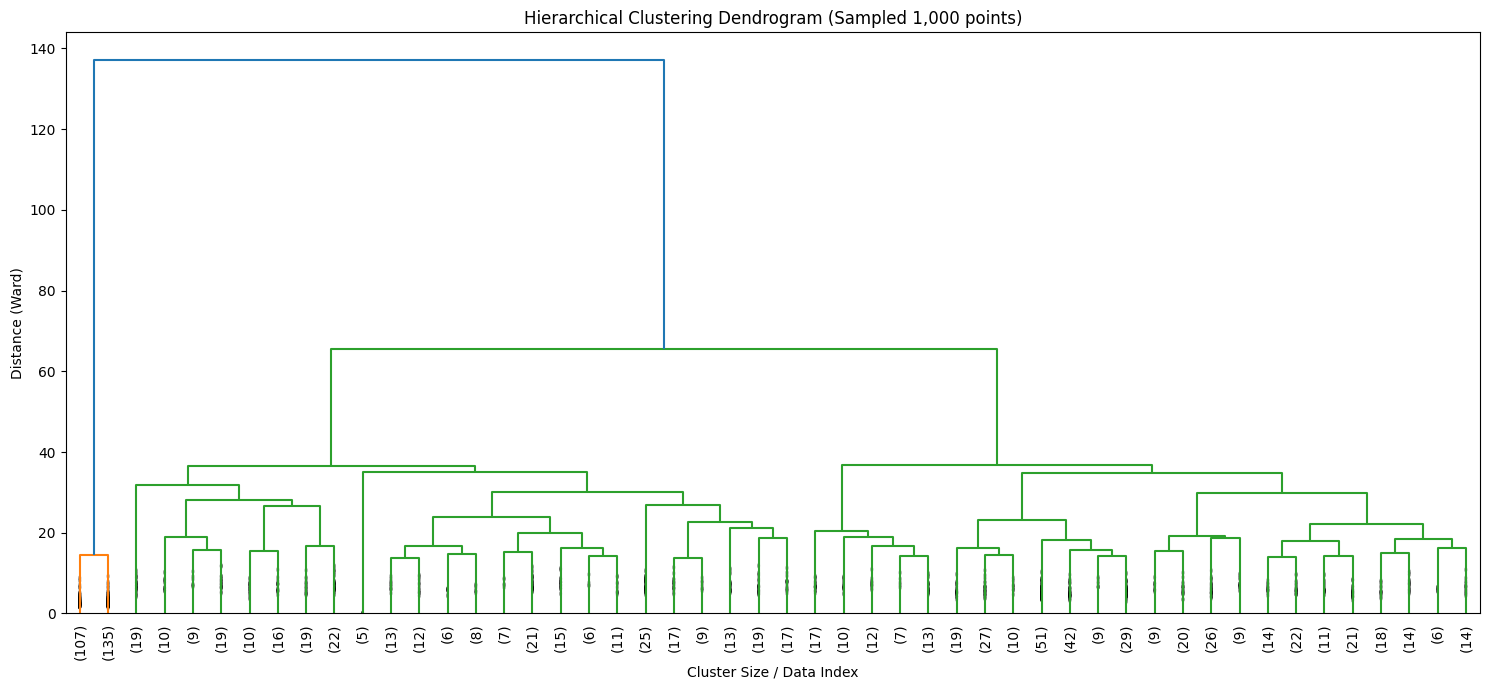

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# 1. 메모리 에러 방지를 위해 1,000개 데이터 샘플링
sample_size = 1000
np.random.seed(42)

# 앞서 만든 50차원으로 축소된 reduced_embeddings 사용
sample_indices = np.random.choice(len(reduced_embeddings), sample_size, replace=False)
sample_data = reduced_embeddings[sample_indices]

# 2. 계층적 군집화 수행 (Ward 연결법: 군집 내 분산을 최소화하는 방식)
print("덴드로그램 계산 중 (샘플링 데이터 1,000개)...")
linked = linkage(sample_data, method='ward')

# 3. 덴드로그램 시각화
plt.figure(figsize=(15, 7))
dendrogram(linked,
           truncate_mode='lastp',  # 그래프가 너무 복잡해지는 것을 막기 위해 하위 노드 압축
           p=50,                   # 화면에 표시할 최대 군집(잎 노드)의 개수
           leaf_rotation=90.,
           leaf_font_size=10.,
           show_contracted=True)

plt.title('Hierarchical Clustering Dendrogram (Sampled 1,000 points)')
plt.xlabel('Cluster Size / Data Index')
plt.ylabel('Distance (Ward)')

# (선택) 적절한 거리(Distance)에서 선을 그어 군집이 나뉘는 모습 확인
# plt.axhline(y=10, color='r', linestyle='--') # y값은 출력된 그래프의 y축 스케일을 보고 조절하세요

plt.tight_layout()
plt.show()

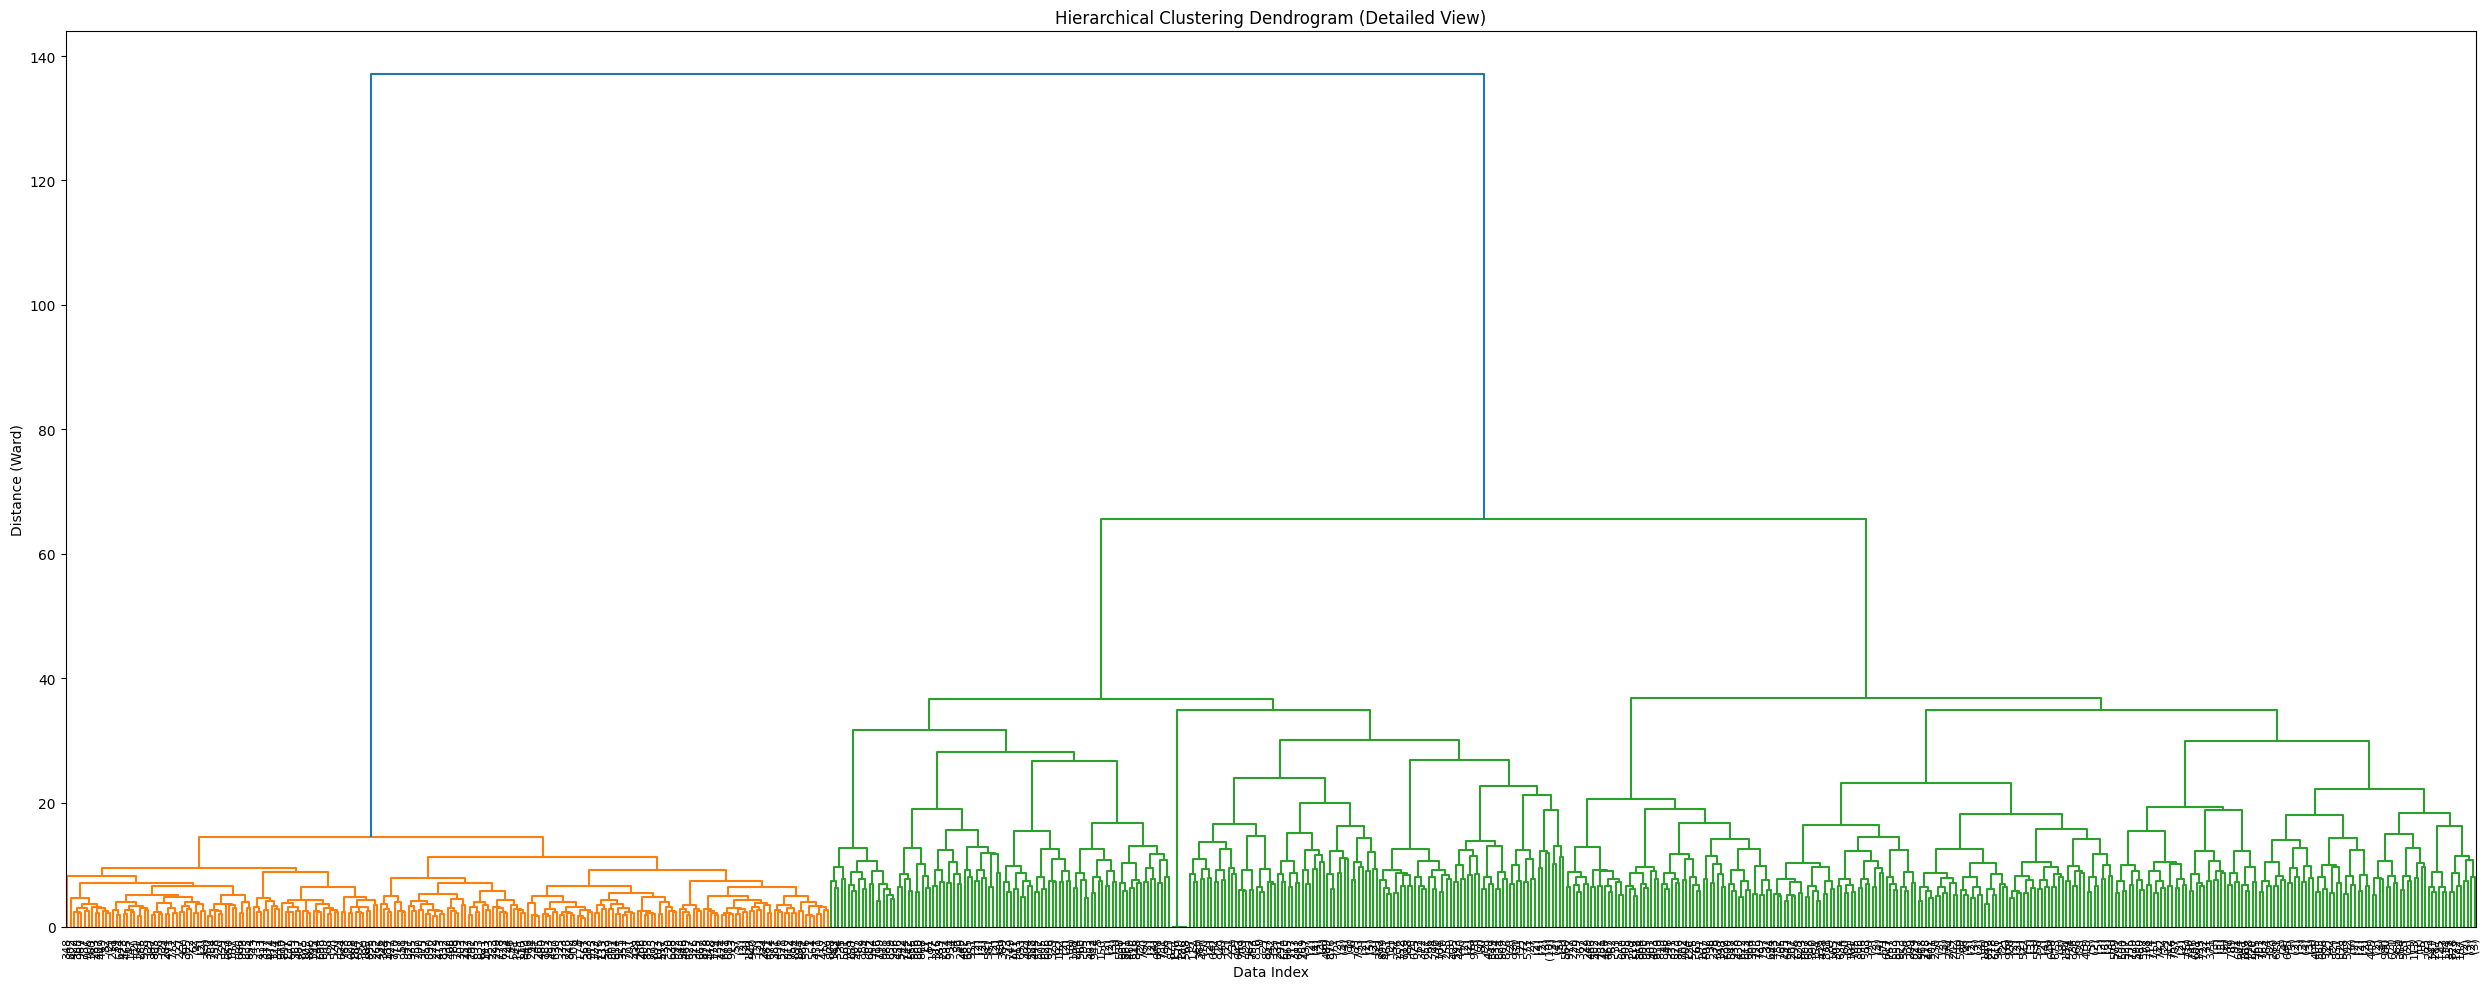

In [ ]:
plt.figure(figsize=(25, 10)) # 가로 크기를 대폭 늘려서 세밀한 선들이 잘 보이게 함

dendrogram(linked,
           # truncate_mode='lastp',  # 이 두 줄을 주석 처리하면
           # p=50,                   # 1,000개 데이터의 전체 트리가 출력됩니다.
           truncate_mode='level',    # 대신 트리의 깊이(level)를 기준으로 보여주는 옵션을 쓸 수도 있습니다.
           p=10,                     # 위에서부터 10단계까지 내려가며 보여줌 (전체를 보려면 이 두 줄도 지우면 됩니다)
           leaf_rotation=90.,
           leaf_font_size=8.,
           show_contracted=True)

plt.title('Hierarchical Clustering Dendrogram (Detailed View)')
plt.xlabel('Data Index')
plt.ylabel('Distance (Ward)')

plt.tight_layout()
plt.show()

# clustering

In [ ]:
from sklearn.cluster import KMeans

# 1. k=3로 클러스터링 실행
kmeans3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['cluster_k3'] = kmeans3.fit_predict(embeddings)


In [ ]:
print("--- [k=3] 군집별 분포 ---")
print(df['cluster_k3'].value_counts().sort_index())

--- [k=3] 군집별 분포 ---
cluster_k3
0    23134
1    15001
2    20431
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. 중복 데이터 확인하기
# '통합본문' 열을 기준으로 완전히 똑같은 데이터가 몇 개인지 확인합니다.
duplicate_count = df.duplicated(subset=['본문']).sum()
print(f"🚨 현재 데이터프레임 내 중복된 텍스트 수: {duplicate_count}개")

🚨 현재 데이터프레임 내 중복된 텍스트 수: 239개


In [ ]:
df_ = df.drop_duplicates(subset=['본문'], keep='first').reset_index(drop=True)

In [ ]:
df

,제목,본문,token,embedding,cluster,cluster_k3
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']","[-0.5792470574378967, -0.3509799838066101, -0....",2,0
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']","[-0.6158533692359924, -0.061289992183446884, 0...",2,0
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...","[-0.14360012114048004, -0.005446251481771469, ...",0,2
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...","[-0.5051539540290833, -0.6635602712631226, 0.2...",2,0
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']","[-0.8485231399536133, -0.4335775673389435, 0.0...",0,2
...,...,...,...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다...","[-0.4979175627231598, -0.26332905888557434, 0....",2,0
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '...","[-0.42004770040512085, -0.21702244877815247, -...",2,0
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '...","[-0.11241494119167328, -0.6430460810661316, -0...",0,2
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자...","[-0.7162784934043884, -0.28542742133140564, 0....",2,0


In [ ]:
df = df.drop(columns=['cluster'])

In [ ]:
df

,제목,본문,token,embedding,cluster_k3
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"['가족', '엘베', '타다', '고역', '겠다', '어떻다', '사다']","[-0.5792470574378967, -0.3509799838066101, -0....",0
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"['엘베', '층간소음', '다투다', '벽', '세탁기', '돌리다']","[-0.6158533692359924, -0.061289992183446884, 0...",0
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"['서대구역', '구역', '들다', '단지', '정확하다', '모르다', '부실'...","[-0.14360012114048004, -0.005446251481771469, ...",2
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"['아파트', '층간소음', '불만', '충', '나무', '아파트', '강제', ...","[-0.5051539540290833, -0.6635602712631226, 0.2...",0
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"['정신병', '이웃', '난', '불다', '조현병', '같다', '두다']","[-0.8485231399536133, -0.4335775673389435, 0.0...",2
...,...,...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"['층간소음', '충', '왜', '잠도', '안', '자고', '나가다', '않다...","[-0.4979175627231598, -0.26332905888557434, 0....",0
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"['매일', '늦다', '시간', '워킹', '패드', '하다', '층간소음', '...","[-0.42004770040512085, -0.21702244877815247, -...",0
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"['혹시', '층간소음', '일지', '및', '동영상', '민사', '준비', '...","[-0.11241494119167328, -0.6430460810661316, -0...",2
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"['주말', '외출', '하다', '꼴다', '보다', '집', '시끄럽다', '자...","[-0.7162784934043884, -0.28542742133140564, 0....",0


In [ ]:
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. 토큰 결합 (띄어쓰기 기반 문자열로 변환)
def join_tokens(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            pass
    if isinstance(x, list):
        return " ".join(x)
    return str(x)

print("1. 토큰 결합 중...")
df['joined_tokens'] = df['token'].apply(join_tokens)

# 2. 군집별 텍스트 병합
print("2. 군집별 텍스트 병합 중...")
cluster_docs = df.groupby('cluster_k3')['joined_tokens'].apply(lambda x: " ".join(x)).reset_index()

# 3. TF-IDF 계산 (상위 단어가 풍부하게 뽑히도록 max_features를 5,000으로 확장)
print("3. TF-IDF 계산 중...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000, min_df=2)
tfidf_matrix = tfidf_vectorizer.fit_transform(cluster_docs['joined_tokens'])

feature_names = tfidf_vectorizer.get_feature_names_out()
dense_matrix = tfidf_matrix.todense()

# 4. 이미지와 동일한 2열 병렬 구조의 딕셔너리 빌딩
print("4. 결과 테이블 구축 중...")
result_table_dict = {}

for i in range(len(cluster_docs)):
    cluster_num = cluster_docs.iloc[i]['cluster_k3']

    # 현재 군집의 점수 매칭 및 정렬
    cluster_scores = dense_matrix[i].tolist()[0]
    word_scores = [(feature_names[j], cluster_scores[j]) for j in range(len(feature_names))]
    word_scores = sorted(word_scores, key=lambda x: x[1], reverse=True)[:40] # 상위 40개 추출

    # 단어 리스트와 점수 리스트로 각각 분리
    keywords = [ws[0] for ws in word_scores]
    scores = [ws[1] for ws in word_scores]

    # 이미지 속 컬럼명 규칙 매칭 (Cluster X Keyword, Cluster X Score)
    result_table_dict[f'Cluster {cluster_num} Keyword'] = keywords
    result_table_dict[f'Cluster {cluster_num} Score'] = scores

# 5. 최종 데이터프레임 생성 및 확인
tfidf_result_df = pd.DataFrame(result_table_dict)
print("🎯 TF-IDF 테이블 생성 완료!")
display(tfidf_result_df)

# (선택) 이 결과를 엑셀 파일로 바로 내보내서 크게 보고 싶다면 아래 주석을 해제하세요.
# tfidf_result_df.to_excel("cluster_tfidf_top40.xlsx", index=False)

1. 토큰 결합 중...
2. 군집별 텍스트 병합 중...
3. TF-IDF 계산 중...
4. 결과 테이블 구축 중...
🎯 TF-IDF 테이블 생성 완료!


,Cluster 0 Keyword,Cluster 0 Score,Cluster 1 Keyword,Cluster 1 Score,Cluster 2 Keyword,Cluster 2 Score
0,하다,0.711851,하다,0.745121,하다,0.813645
1,층간소음,0.294618,회원,0.327175,있다,0.233607
2,소리,0.279767,행위,0.261593,되다,0.156005
3,있다,0.211942,카페,0.199864,소리,0.146695
4,소음,0.144603,사항,0.196010,없다,0.142855
5,없다,0.137576,욕설,0.131086,보다,0.141473
6,아이,0.136381,소리,0.116007,같다,0.130174
7,같다,0.120966,되다,0.105776,아니다,0.105725
8,아니다,0.110674,인신,0.084073,아이,0.093100
9,되다,0.109955,있다,0.077174,좋다,0.088708


In [ ]:
# ==========================================
# STEP 1: 원본 df에서 불용어 먼저 제거하기
# ==========================================
stop_words = {'하다', '있다', '되다', '보다'}

def clean_tokens(x):
    # 문자열 형태의 리스트라면 실제 리스트로 변환
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            pass
    if isinstance(x, list):
        # 정의한 불용어에 포함되지 않는 단어만 남기기
        return [word for word in x if word not in stop_words]
    return x

print("1. 원본 df['token']에서 불용어 제거 중...")
df['token'] = df['token'].apply(clean_tokens)

# 토큰을 띄어쓰기 기반 문자열로 변환하여 새 컬럼에 저장
df['tokens'] = df['token'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

1. 원본 df['token']에서 불용어 제거 중...


In [ ]:
df

,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"[가족, 엘베, 타다, 고역, 겠다, 어떻다, 사다]","[-0.5792470574378967, -0.3509799838066101, -0....",0,가족 엘베 타다 고역 겠다 어떻다 사다,가족 엘베 타다 고역 겠다 어떻다 사다
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"[엘베, 층간소음, 다투다, 벽, 세탁기, 돌리다]","[-0.6158533692359924, -0.061289992183446884, 0...",0,엘베 층간소음 다투다 벽 세탁기 돌리다,엘베 층간소음 다투다 벽 세탁기 돌리다
2,NaN,서대구역 구역 이라고 들었는데 단지인지 정확히는 잘모르겠지만 부실공사에 제값보다 고...,"[서대구역, 구역, 들다, 단지, 정확하다, 모르다, 부실, 공사, 값, 평가, 아...","[-0.14360012114048004, -0.005446251481771469, ...",2,서대구역 구역 들다 단지 정확하다 모르다 부실 공사 값 평가 되다 아파트 맞다,서대구역 구역 들다 단지 정확하다 모르다 부실 공사 값 평가 아파트 맞다
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"[아파트, 층간소음, 불만, 충, 나무, 아파트, 강제, 살, 법, 만듭시]","[-0.5051539540290833, -0.6635602712631226, 0.2...",0,아파트 층간소음 불만 충 나무 아파트 강제 살 하다 법 만듭시,아파트 층간소음 불만 충 나무 아파트 강제 살 법 만듭시
4,NaN,정신병자를 이웃으로만난게 불운이였다 조현병같은데 둔거야,"[정신병, 이웃, 난, 불다, 조현병, 같다, 두다]","[-0.8485231399536133, -0.4335775673389435, 0.0...",2,정신병 이웃 난 불다 조현병 같다 두다,정신병 이웃 난 불다 조현병 같다 두다
...,...,...,...,...,...,...,...
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"[층간소음, 충, 왜, 잠도, 안, 자고, 나가다, 않다, 집, 구석, 지랄, 들이...","[-0.4979175627231598, -0.26332905888557434, 0....",0,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"[매일, 늦다, 시간, 워킹, 패드, 층간소음, 층간소음, 웈웈웈웅, 집, 웠윗집,...","[-0.42004770040512085, -0.21702244877815247, -...",0,매일 늦다 시간 워킹 패드 하다 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,매일 늦다 시간 워킹 패드 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥
58620,층간소음 일지&증거 민사+관리사무소+이웃사이센터,혹시 층간소음 일지 및 동영상으로 민사를 준비하고 있는데 소음일지 작성 동영상 증거...,"[혹시, 층간소음, 일지, 및, 동영상, 민사, 준비, 소음, 일지, 작성, 동영상...","[-0.11241494119167328, -0.6430460810661316, -0...",2,혹시 층간소음 일지 및 동영상 민사 준비 있다 소음 일지 작성 동영상 증거 경찰 출...,혹시 층간소음 일지 및 동영상 민사 준비 소음 일지 작성 동영상 증거 경찰 출동 일...
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"[주말, 외출, 꼴다, 집, 시끄럽다, 자주, 나가다, 도해]","[-0.7162784934043884, -0.28542742133140564, 0....",0,주말 외출 하다 꼴다 보다 집 시끄럽다 자주 나가다 도해,주말 외출 꼴다 집 시끄럽다 자주 나가다 도해


# cluster 0 토픽 추출

🎯 Cluster 0 데이터 개수: 23134개
Cluster 0의 최적 하위 토픽 수(K)를 계산 중입니다...
연산 완료! 결과를 그래프로 출력합니다.


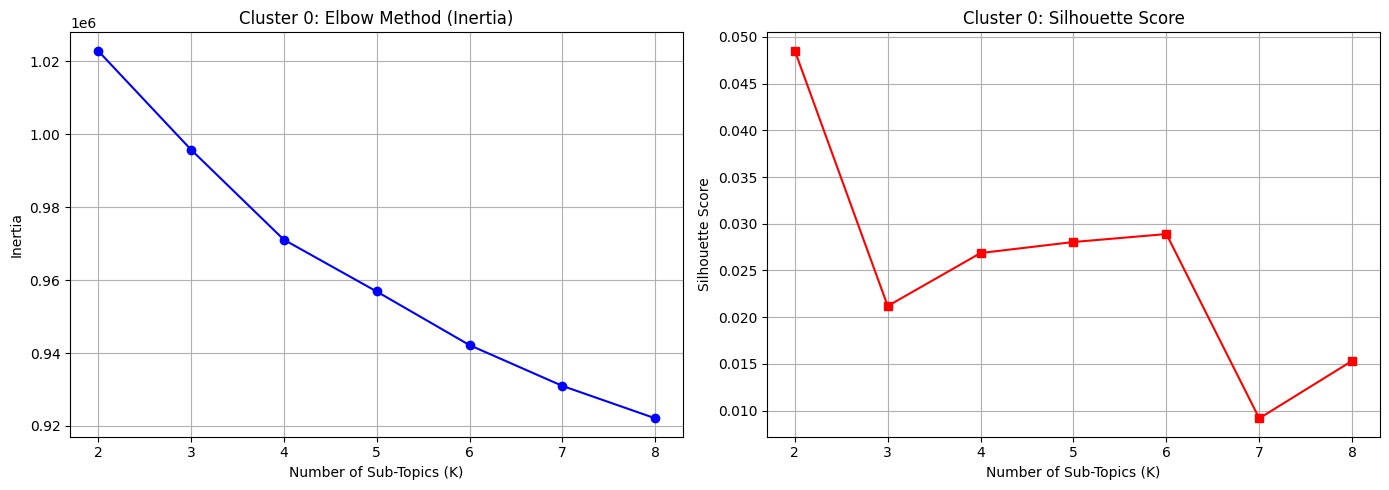

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Cluster 0 데이터만 필터링하여 새로운 데이터프레임 생성
df_cluster0 = df[df['cluster_k3'] == 0].reset_index(drop=True)
print(f"🎯 Cluster 0 데이터 개수: {len(df_cluster0)}개")

# 2. Cluster 0의 임베딩 배열만 추출
X_c0 = np.stack(df_cluster0['embedding'].values)

# 3. 탐색할 하위 토픽 개수(K) 범위 설정
# 세부 토픽이므로 2~8개까지만 탐색합니다. (데이터 개수에 따라 조절 가능)
k_range_c0 = range(2, 9)

inertias_c0 = []
silhouette_scores_c0 = []

print("Cluster 0의 최적 하위 토픽 수(K)를 계산 중입니다...")

# 4. K값을 늘려가며 KMeans 학습 및 지표 계산
for k in k_range_c0:
    kmeans_c0 = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_c0 = kmeans_c0.fit_predict(X_c0)

    # 엘보우 기법을 위한 Inertia(오차제곱합) 저장
    inertias_c0.append(kmeans_c0.inertia_)

    # 실루엣 점수 저장
    silhouette_scores_c0.append(silhouette_score(X_c0, labels_c0))

print("연산 완료! 결과를 그래프로 출력합니다.")

# 5. 시각화 (1행 2열)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 엘보우 기법 그래프
ax1.plot(k_range_c0, inertias_c0, marker='o', linestyle='-', color='blue')
ax1.set_title('Cluster 0: Elbow Method (Inertia)')
ax1.set_xlabel('Number of Sub-Topics (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range_c0)
ax1.grid(True)

# [오른쪽] 실루엣 점수 그래프
ax2.plot(k_range_c0, silhouette_scores_c0, marker='s', linestyle='-', color='red')
ax2.set_title('Cluster 0: Silhouette Score')
ax2.set_xlabel('Number of Sub-Topics (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range_c0)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Cluster 0 데이터만 독립적인 데이터프레임으로 복사
df_c0 = df[df['cluster_k3'] == 0].copy().reset_index(drop=True)
X_c0 = np.stack(df_c0['embedding'].values)

# 2. K으로 세부 클러스터링 진행
n_cluster = 4
kmeans_c0 = KMeans(n_clusters=n_cluster, random_state=42, n_init='auto')
df_c0['sub_cluster'] = kmeans_c0.fit_predict(X_c0)

print("✨ Cluster 0의 세부 토픽(3개) 분리가 완료되었습니다!\n")
print("📊 [세부 토픽별 데이터 개수]")
print(df_c0['sub_cluster'].value_counts().sort_index())
print("\n==================================================")
print(" 🎯 [Cluster 0 하위 토픽 프로파일링: 키워드 + 대표 원문]")
print("==================================================")

# 3. c-TF-IDF를 위한 텍스트 병합 (이전 단계에서 만든 joined_tokens 활용)
cluster_docs_c0 = df_c0.groupby('sub_cluster')['joined_tokens'].apply(lambda x: " ".join(x)).reset_index()

tfidf_c0 = TfidfVectorizer(max_df=0.9, min_df=2)
tfidf_matrix_c0 = tfidf_c0.fit_transform(cluster_docs_c0['joined_tokens'])
feature_names_c0 = tfidf_c0.get_feature_names_out()

# 4. 각 하위 토픽별 핵심 단어(15개)와 중심 원문(2개) 추출
for i, sub_id in enumerate(cluster_docs_c0['sub_cluster']):
    print(f"\n▶️ [Sub-Topic {sub_id}]")

    # 핵심 단어 추출
    tfidf_scores = tfidf_matrix_c0[i].toarray()[0]
    top_indices = tfidf_scores.argsort()[::-1][:15]
    top_keywords = [feature_names_c0[idx] for idx in top_indices]
    print(f"🔑 핵심 단어: {', '.join(top_keywords)}")
    print("-" * 50)

    # 중심점 기반 대표 원문 추출
    sub_data = df_c0[df_c0['sub_cluster'] == sub_id].reset_index(drop=True)
    sub_embeddings = np.stack(sub_data['embedding'].values)
    centroid = sub_embeddings.mean(axis=0).reshape(1, -1)

    similarities = cosine_similarity(sub_embeddings, centroid).flatten()
    top_doc_indices = similarities.argsort()[::-1][:2]

    for rank, idx in enumerate(top_doc_indices):
        doc_text = sub_data.loc[idx, '본문']
        sim_score = similarities[idx]
        print(f"📄 [대표 원문 {rank+1} | 중심 유사도: {sim_score:.4f}]")
        print(f"{str(doc_text)[:250]}...\n") # 가독성을 위해 250자로 제한

✨ Cluster 0의 세부 토픽(3개) 분리가 완료되었습니다!

📊 [세부 토픽별 데이터 개수]
sub_cluster
0    8178
1    6553
2    4085
3    4318
Name: count, dtype: int64

 🎯 [Cluster 0 하위 토픽 프로파일링: 키워드 + 대표 원문]

▶️ [Sub-Topic 0]
🔑 핵심 단어: 세면대, 작은방, 일정하다, 요란하다, 접기, 드라이기, 벌렁, 죽겠네, 수격, 문소리, 월요일, 가습기, 웅웅웅, 날씨, 고요하다
--------------------------------------------------
📄 [대표 원문 1 | 중심 유사도: 0.9136]
윗집 층간소음 심한데 방법 없나요 화장실에서 노래 틀기 이런거는 밑에 집에도 피해가는거 아닌가요 위에 집한테만 피해주고 싶거든요 밑에 아주머니는 착하셔서 맨날 쿵쿵 거리고 드르륵 소리나고 쿵쿵거려서 이제는 진동이 느껴지는 정도임 쓰는 지금도 시끄러움 던지는 느낌임 사람이 쿵쿵거린다고 개빡치네 새벽 시까지 쿵쿵거림 마시고 토하는지 새벽에 우웩거리는 소리도 들림 미치겠네...

📄 [대표 원문 2 | 중심 유사도: 0.9117]
진짜 새벽부터 새벽까지 층간소음에 가구 끄는소리 일부러 내는 망치질 하는 층간소음층간소음 소리 생활소음과 다른 데시벨 때문에 정신병 올것같은데 윗집이 소리를 스피커로 틀어둔건가 싶을정도로 하루종일 쉴틈없이 나서요 직접 찾아이는건 최대한 피하고 싶은데 해결 방법이 없을까요 이나 고망 쓰고싶은데 가족들도 같이 사는 집이라 크게 소음내기가 어려워서요...


▶️ [Sub-Topic 1]
🔑 핵심 단어: 작은방, 친정, 독립, 라멘, 해피, 손주, 복비, 고요하다, 손자, 타워, 행복, 유모차, 따뜻하다, 만기, 문소리
--------------------------------------------------
📄 [대표 원문 1 | 중심 유사도: 0.9118]
윗집은 최근 이사오자마자 층간소음 물건 떨구는 소음 난리나고 

# cluster 2 토픽 추출

🎯 Cluster 2 데이터 개수: 20431개
Cluster 2의 최적 하위 토픽 수(K)를 계산 중입니다...
연산 완료! 결과를 그래프로 출력합니다.


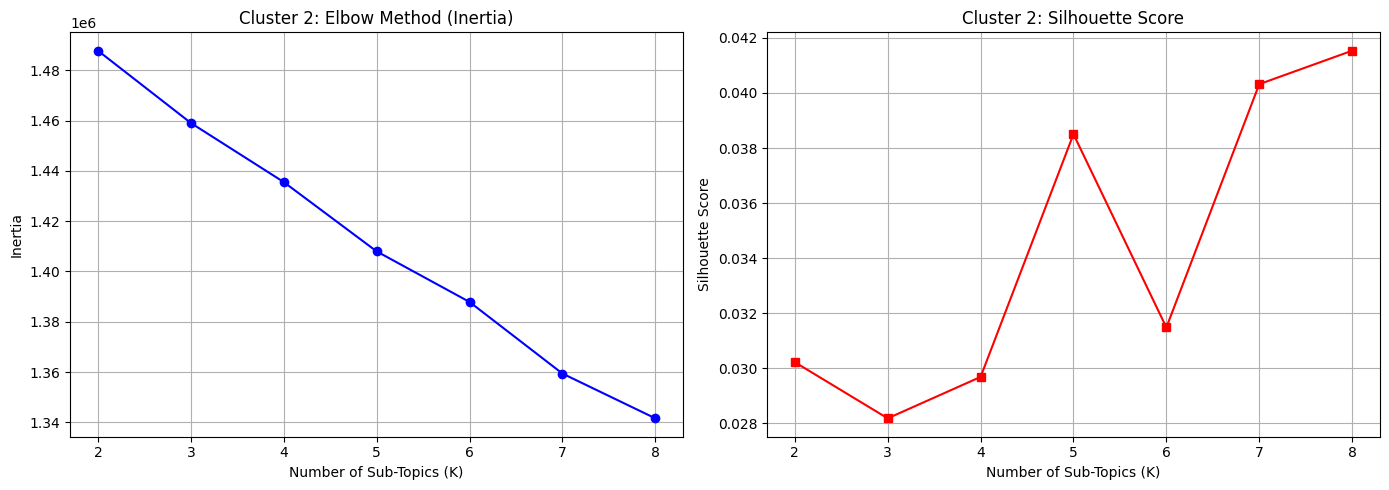

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Cluster 2 데이터만 필터링하여 새로운 데이터프레임 생성
df_cluster2 = df[df['cluster_k3'] == 2].reset_index(drop=True)
print(f"🎯 Cluster 2 데이터 개수: {len(df_cluster2)}개")

# 2. Cluster 2의 임베딩 배열만 추출
X_c2 = np.stack(df_cluster2['embedding'].values)

# 3. 탐색할 하위 토픽 개수(K) 범위 설정
# 세부 토픽이므로 2~8개까지만 탐색합니다. (데이터 개수에 따라 조절 가능)
k_range_c2 = range(2, 9)

inertias_c2 = []
silhouette_scores_c2 = []

print("Cluster 2의 최적 하위 토픽 수(K)를 계산 중입니다...")

# 4. K값을 늘려가며 KMeans 학습 및 지표 계산
for k in k_range_c2:
    kmeans_c2 = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_c2 = kmeans_c2.fit_predict(X_c2)

    # 엘보우 기법을 위한 Inertia(오차제곱합) 저장
    inertias_c2.append(kmeans_c2.inertia_)

    # 실루엣 점수 저장
    silhouette_scores_c2.append(silhouette_score(X_c2, labels_c2))

print("연산 완료! 결과를 그래프로 출력합니다.")

# 5. 시각화 (1행 2열)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# [왼쪽] 엘보우 기법 그래프
ax1.plot(k_range_c2, inertias_c2, marker='o', linestyle='-', color='blue')
ax1.set_title('Cluster 2: Elbow Method (Inertia)')
ax1.set_xlabel('Number of Sub-Topics (K)')
ax1.set_ylabel('Inertia')
ax1.set_xticks(k_range_c2)
ax1.grid(True)

# [오른쪽] 실루엣 점수 그래프
ax2.plot(k_range_c2, silhouette_scores_c2, marker='s', linestyle='-', color='red')
ax2.set_title('Cluster 2: Silhouette Score')
ax2.set_xlabel('Number of Sub-Topics (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range_c2)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Cluster 2 데이터만 독립적인 데이터프레임으로 복사
df_c2 = df[df['cluster_k3'] == 2].copy().reset_index(drop=True)
X_c2 = np.stack(df_c2['embedding'].values)

# 2. K으로 세부 클러스터링 진행
n_cluster = 5
kmeans_c2 = KMeans(n_clusters=n_cluster, random_state=42, n_init='auto')
df_c2['sub_cluster'] = kmeans_c2.fit_predict(X_c2)

print("✨ Cluster 2의 세부 토픽(5개) 분리가 완료되었습니다!\n")
print("📊 [세부 토픽별 데이터 개수]")
print(df_c2['sub_cluster'].value_counts().sort_index())
print("\n==================================================")
print(" 🎯 [Cluster 2 하위 토픽 프로파일링: 키워드 + 대표 원문]")
print("==================================================")

# 3. c-TF-IDF를 위한 텍스트 병합 (이전 단계에서 만든 joined_tokens 활용)
cluster_docs_c2 = df_c2.groupby('sub_cluster')['joined_tokens'].apply(lambda x: " ".join(x)).reset_index()

tfidf_c2 = TfidfVectorizer(max_df=0.9, min_df=2)
tfidf_matrix_c2 = tfidf_c2.fit_transform(cluster_docs_c2['joined_tokens'])
feature_names_c2 = tfidf_c2.get_feature_names_out()

# 4. 각 하위 토픽별 핵심 단어(15개)와 중심 원문(2개) 추출
for i, sub_id in enumerate(cluster_docs_c2['sub_cluster']):
    print(f"\n▶️ [Sub-Topic {sub_id}]")

    # 핵심 단어 추출
    tfidf_scores = tfidf_matrix_c2[i].toarray()[0]
    top_indices = tfidf_scores.argsort()[::-1][:15]
    top_keywords = [feature_names_c2[idx] for idx in top_indices]
    print(f"🔑 핵심 단어: {', '.join(top_keywords)}")
    print("-" * 50)

    # 중심점 기반 대표 원문 추출
    sub_data = df_c2[df_c2['sub_cluster'] == sub_id].reset_index(drop=True)
    sub_embeddings = np.stack(sub_data['embedding'].values)
    centroid = sub_embeddings.mean(axis=0).reshape(1, -1)

    similarities = cosine_similarity(sub_embeddings, centroid).flatten()
    top_doc_indices = similarities.argsort()[::-1][:2]

    for rank, idx in enumerate(top_doc_indices):
        doc_text = sub_data.loc[idx, '본문']
        sim_score = similarities[idx]
        print(f"📄 [대표 원문 {rank+1} | 중심 유사도: {sim_score:.4f}]")
        print(f"{str(doc_text)[:250]}...\n") # 가독성을 위해 250자로 제한

✨ Cluster 2의 세부 토픽(5개) 분리가 완료되었습니다!

📊 [세부 토픽별 데이터 개수]
sub_cluster
0    5129
1    5787
2    3807
3    5495
4     213
Name: count, dtype: int64

 🎯 [Cluster 2 하위 토픽 프로파일링: 키워드 + 대표 원문]

▶️ [Sub-Topic 0]
🔑 핵심 단어: 하다, 있다, 되다, 없다, 보다, 같다, 좋다, 아니다, 이다, 않다, 가다, 쓰다, 그렇다, 소리, 소음
--------------------------------------------------
📄 [대표 원문 1 | 중심 유사도: 0.7738]
조심히 다루는데 뭔넘의 옆에 잔기스가 많은지 문콕 짜증나네요 뭔가 법을 제대로 다듬던가 아니면 자동차회사에서 뭔가 획기적인 발명품을 놓던가...

📄 [대표 원문 2 | 중심 유사도: 0.7707]
이걸 봐주고 뭘넘어가 저걸 옆에 서잇는 사람이라고 치고 엘보우로 배때려봐 아퍼안아퍼 근대 넘어가 병원가자나 망치질 한거나 마찬가지인대 실수 고의 뺑소니 분명 알어 문을 열면서 닿는 소리가 나는대 아무것도없는 넓은곳이면 문제 없는대 소리가나자나 그걸 무시하고넘어가면 나중에 자가 똑같이 넘어갓는대 속안뒤집이겠어...


▶️ [Sub-Topic 1]
🔑 핵심 단어: 하다, 있다, 없다, 되다, 아니다, 보다, 같다, 받다, 경찰, 않다, 아이, 그렇다, 들다, 이다, 생각
--------------------------------------------------
📄 [대표 원문 1 | 중심 유사도: 0.8186]
오늘 글삭튀하네 나같은 놈때메 층간소음 살인난다고 도망가지나 말래 칼 앞에 서봤냐 난 서봤음 허벅지도 베여서 흉터도 있는데 상처 크지 않아서 공상처리도 안하고 그냥 자연치유함 이런거 기사한줄 날거 같아이 나같은 놈 때문에 살인난다고 너같은 놈 때문에 도망가야겠다 이제 사명감 박살내줘서 고오맙다 발단 직원이 지하차도 112가 통제신고 들어왔으니

In [ ]:
# 파일명 지정 (원하시는 이름으로 수정 가능합니다)
save_path = 'cluster2_sub_topics_5개로.pkl'

# df_c2 데이터프레임을 pickle 형식으로 저장
df_c2.to_pickle(save_path)

print(f"✅ Cluster 2 세부 토픽 데이터가 '{save_path}' 파일로 안전하게 저장되었습니다!")

✅ Cluster 2 세부 토픽 데이터가 'cluster2_sub_topics_5개로.pkl' 파일로 안전하게 저장되었습니다!


In [ ]:
# 파일명 지정 (원하시는 이름으로 수정 가능합니다)
save_path = 'cluster0_sub_topics_4개로.pkl'

# df_c2 데이터프레임을 pickle 형식으로 저장
df_c0.to_pickle(save_path)

print(f"✅ Cluster 2 세부 토픽 데이터가 '{save_path}' 파일로 안전하게 저장되었습니다!")

✅ Cluster 2 세부 토픽 데이터가 'cluster0_sub_topics_4개로.pkl' 파일로 안전하게 저장되었습니다!


# LDA

In [ ]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# 1. 통합본에 남기고 싶은 필수 칼럼(열) 리스트 정의
columns_to_keep = [
    '제목', '본문',
    'token',  'embedding',
    'cluster_k3', 'sub_cluster'
]

print("데이터프레임들을 하나로 합치는 중입니다...")

# 2. 각 데이터프레임에서 필요한 열만 필터링한 후, 하나의 리스트로 묶기
dfs_to_concat = [
    df_c0[columns_to_keep],
    df_c2[columns_to_keep]
]

# 3. 데이터프레임들을 위아래로 병합 (ignore_index=True로 기존 인덱스를 깔끔하게 리셋)
df_cluster_topic = pd.concat(dfs_to_concat, ignore_index=True)

# 4. 통합된 데이터 확인
print("✨ 4개의 세부 토픽 데이터가 하나로 완벽하게 통합되었습니다!")
print(f"📊 총 데이터 개수: {len(df_cluster_topic)}개")
print(f"✅ 남겨진 열(Columns): {list(df_cluster_topic.columns)}\n")

# 5. 임베딩 배열(embeddings) 유지를 위해 pickle 형식으로 최종 저장
save_path = 'df_cluster_topic.pkl'
df_cluster_topic.to_pickle(save_path)
print(f"💾 통합된 데이터프레임이 '{save_path}'로 안전하게 저장되었습니다.")

# 데이터프레임 상위 3줄 미리보기
display(df_cluster_topic.head(20))

데이터프레임들을 하나로 합치는 중입니다...
✨ 4개의 세부 토픽 데이터가 하나로 완벽하게 통합되었습니다!
📊 총 데이터 개수: 43565개
✅ 남겨진 열(Columns): ['제목', '본문', 'token', 'embedding', 'cluster_k3', 'sub_cluster']

💾 통합된 데이터프레임이 'df_cluster_topic.pkl'로 안전하게 저장되었습니다.


,제목,본문,token,embedding,cluster_k3,sub_cluster
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"[가족, 엘베, 타다, 고역, 겠다, 어떻다, 사다]","[-0.5792470574378967, -0.3509799838066101, -0....",0,3
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"[엘베, 층간소음, 다투다, 벽, 세탁기, 돌리다]","[-0.6158533692359924, -0.061289992183446884, 0...",0,0
2,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"[아파트, 층간소음, 불만, 충, 나무, 아파트, 강제, 살, 법, 만듭시]","[-0.5051539540290833, -0.6635602712631226, 0.2...",0,2
3,NaN,윗집 남자 피해자 죽임당하셔구냐 불쌍해요 층간소음 윗층 할머니 새벽 시에 믹서기 돌...,"[집, 남자, 피해자, 죽이다, 당하다, 구, 불쌍하다, 층간소음, 층, 할머니, ...","[-0.6405828595161438, -0.6092670559883118, 0.2...",0,0
4,NaN,아파트란게 윗층 소음만 들리는게 아니더라 윗층 올라가보니 애기들도 없는데 아래서는 ...,"[아파트, 란, 층, 소음, 들리다, 아니다, 층, 올라가다, 애기, 없다, 아래,...","[-0.13890789449214935, -0.33729928731918335, -...",0,3
5,NaN,소음이 스트레스면 단독주택살아야지 떠라이네,"[소음, 스트레스, 단독주택, 살다, 뜨다, 라이네]","[-0.02113264426589012, -0.2820363938808441, 0....",0,1
6,NaN,공공주택 물소리는 당연히 나지 예민하면 따로 단독주택 사서 나가 살아야지 능력은 안...,"[주택, 물, 소리, 당연하다, 나다, 예민하다, 단독주택, 사서, 나가다, 살다,...","[-0.37106576561927795, -0.47914138436317444, 0...",0,1
7,NaN,윗집 인줄 알았는데 윗윗층 대각선 이더라구요 윗집처럼 느껴졌는데 그후로는 쾅쾅대도 ...,"[집, 이다, 알다, 층, 대각선, 이다, 집, 느껴지다, 후, 쾅쾅대다, 가부, 다해]","[-0.5943214297294617, -0.26362136006355286, 0....",0,1
8,NaN,도대체 어떻게 지었길래 독립할때 오피스텔은 소음이 심하다고 걱정했는데 사는 오피스텔...,"[도대체, 어떻다, 지다, 독립, 오피스텔, 소음, 심하다, 걱정, 살다, 오피스텔...","[-0.2739018201828003, -0.3918933868408203, -0....",0,1
9,NaN,정신병자네요 아래집 인간 살면 답없음 매일이 스트레스예요,"[정신병, 자네, 아래, 집, 인간, 살, 답, 없다, 매일, 스트레스]","[-0.9150862693786621, -0.2541632354259491, 0.6...",0,3


In [ ]:
df['cluster_k3'].value_counts()

,count
cluster_k3,
0,23134
2,20431
1,15001


In [ ]:
!pip install pyLDAvis

In [ ]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

In [ ]:
df_cluster0 = df[df['cluster_k3'] == 0]

all_documents = list(df_cluster0['token'])
# 고유한 단어들에 각각 고유한 정수 ID(번호)를 부여하여 사전 만들기
dictionary = Dictionary(all_documents)

In [ ]:
corpus = []
for i in all_documents:
  corpus.append(dictionary.doc2bow(i))

In [ ]:
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 3, id2word = dictionary, random_state = 42)

In [ ]:
align = []

for i in ldamodel.get_document_topics(corpus):
  label = []
  value = []
  for w in i:
    label.append(w[0])
    value.append(w[1])

  align.append(label[np.argmax(value)])

df_cluster0['topic'] = align
df_cluster0

/tmp/ipykernel_1376/1918007607.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cluster0['topic'] = align


,제목,본문,token,embedding,cluster_k3,joined_tokens,tokens,topic
0,NaN,가족들 그엘베 타는거 고역이겠다 어떻게 사냐,"[가족, 엘베, 타다, 고역, 겠다, 어떻다, 사다]","[-0.5792470574378967, -0.3509799838066101, -0....",0,가족 엘베 타다 고역 겠다 어떻다 사다,가족 엘베 타다 고역 겠다 어떻다 사다,2
1,NaN,엘베에서 층간소음으로 다툰적이 전세벽에 세탁기를 돌리시더라구요,"[엘베, 층간소음, 다투다, 벽, 세탁기, 돌리다]","[-0.6158533692359924, -0.061289992183446884, 0...",0,엘베 층간소음 다투다 벽 세탁기 돌리다,엘베 층간소음 다투다 벽 세탁기 돌리다,1
3,NaN,아파트 층간소음 불만충들 나무아파트에서 강제로 살게 하기 법을 만듭시다,"[아파트, 층간소음, 불만, 충, 나무, 아파트, 강제, 살, 법, 만듭시]","[-0.5051539540290833, -0.6635602712631226, 0.2...",0,아파트 층간소음 불만 충 나무 아파트 강제 살 하다 법 만듭시,아파트 층간소음 불만 충 나무 아파트 강제 살 법 만듭시,0
5,NaN,윗집 남자 피해자 죽임당하셔구냐 불쌍해요 층간소음 윗층 할머니 새벽 시에 믹서기 돌...,"[집, 남자, 피해자, 죽이다, 당하다, 구, 불쌍하다, 층간소음, 층, 할머니, ...","[-0.6405828595161438, -0.6092670559883118, 0.2...",0,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,집 남자 피해자 죽이다 당하다 구 불쌍하다 층간소음 층 할머니 새벽 시 믹서기 돌리...,1
7,NaN,아파트란게 윗층 소음만 들리는게 아니더라 윗층 올라가보니 애기들도 없는데 아래서는 ...,"[아파트, 란, 층, 소음, 들리다, 아니다, 층, 올라가다, 애기, 없다, 아래,...","[-0.13890789449214935, -0.33729928731918335, -...",0,아파트 란 층 소음 들리다 아니다 층 올라가다 보다 애기 없다 아래 서다 아기 뛰어다니다,아파트 란 층 소음 들리다 아니다 층 올라가다 애기 없다 아래 서다 아기 뛰어다니다,2
...,...,...,...,...,...,...,...,...
58616,화장실충,진짜 왜 안방 화장실은 안 쓰고 꼭 거실 화장실만 쓸까요 청소하기 귀찮아서 하나는 ...,"[진짜, 왜, 안방, 화장실, 안, 쓰다, 꼭, 거실, 화장실, 쓸다, 요, 청소,...","[-0.3919851779937744, -0.4484711289405823, -0....",0,진짜 왜 안방 화장실 안 쓰다 꼭 거실 화장실 쓸다 요 청소 하다 귀찮다 하나 방치...,진짜 왜 안방 화장실 안 쓰다 꼭 거실 화장실 쓸다 요 청소 귀찮다 하나 방치 중인...,1
58618,13층 미친 것들,층간소음충들은 왜 잠도 안 자고 밖에 나가지도 않고 맨날 집구석에서 지랄들일까요 5...,"[층간소음, 충, 왜, 잠도, 안, 자고, 나가다, 않다, 집, 구석, 지랄, 들이...","[-0.4979175627231598, -0.26332905888557434, 0....",0,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,층간소음 충 왜 잠도 안 자고 나가다 않다 집 구석 지랄 들이다 요 아이 뛰다 동안...,1
58619,아니 발 모가지 분질러야되나요,매일 이 늦은 시간에 워킹패드하는지 층간소음층간소음 웈웈웈웅 하 윗집인지 웟윗집인지...,"[매일, 늦다, 시간, 워킹, 패드, 층간소음, 층간소음, 웈웈웈웅, 집, 웠윗집,...","[-0.42004770040512085, -0.21702244877815247, -...",0,매일 늦다 시간 워킹 패드 하다 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,매일 늦다 시간 워킹 패드 층간소음 층간소음 웈웈웈웅 집 웠윗집 집 지옥 요 지옥,2
58621,이것들은왜 외출도안하나요,주말인데도 외출하는꼴을못보네 아오 집에서 시끄러우면 자주나가기라도해라,"[주말, 외출, 꼴다, 집, 시끄럽다, 자주, 나가다, 도해]","[-0.7162784934043884, -0.28542742133140564, 0....",0,주말 외출 하다 꼴다 보다 집 시끄럽다 자주 나가다 도해,주말 외출 꼴다 집 시끄럽다 자주 나가다 도해,1


In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary) # 적용
pyLDAvis.save_html(prepared_data, 'ldavis_Action_0.html')
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
df_cluster0['topic'].value_counts()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,count
topic,
1,9050
2,8121
0,5963


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 7, id2word = dictionary, random_state = 42)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/

In [ ]:
align = []

for i in ldamodel.get_document_topics(corpus):
  label = []
  value = []
  for w in i:
    label.append(w[0])
    value.append(w[1])

  align.append(label[np.argmax(value)])

df_cluster2['topic'] = align
df_cluster2

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/

In [ ]:
!pip install pyLDAvis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd
df = pd.read_pickle('/content/drive/MyDrive/DX PROJ./임베딩/이걸로/cluster2_sub_topics_5개로.pkl')

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
df_cluster2 = df[df['cluster_k3'] == 2]

all_documents = list(df_cluster2['token'])
# 고유한 단어들에 각각 고유한 정수 ID(번호)를 부여하여 사전 만들기
dictionary = Dictionary(all_documents)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
corpus = []
for i in all_documents:
  corpus.append(dictionary.doc2bow(i))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 4, id2word = dictionary, random_state = 42)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary) # 적용
pyLDAvis.save_html(prepared_data, 'ldavis_Action_2.html')
pyLDAvis.display(prepared_data)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
